# Task 12: Unsupervised Learning & Dimensionality Reduction

## Introduction to Unsupervised Learning

Unsupervised Learning involves finding patterns in data without labeled responses. Key techniques include clustering, dimensionality reduction, and association rule mining.

## 1. Import Libraries

In [79]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

## 2. K-Means Clustering

### Implementing K-Means from Scratch

In [80]:
class KMeansFromScratch:
    """K-Means Clustering implementation from scratch"""
    
    def __init__(self, n_clusters=3, max_iter=100, random_state=42):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.random_state = random_state
        self.centroids = None
        self.labels = None
    
    def fit(self, X):
        np.random.seed(self.random_state)
        n_samples = X.shape[0]
        
        # Initialize centroids randomly
        idx = np.random.choice(n_samples, self.n_clusters, replace=False)
        self.centroids = X[idx]
        
        for _ in range(self.max_iter):
            # Assign points to nearest centroid
            distances = self._compute_distances(X)
            self.labels = np.argmin(distances, axis=1)
            
            # Update centroids
            new_centroids = np.zeros_like(self.centroids)
            for k in range(self.n_clusters):
                if np.sum(self.labels == k) > 0:
                    new_centroids[k] = X[self.labels == k].mean(axis=0)
                else:
                    new_centroids[k] = self.centroids[k]
            
            # Check convergence
            if np.allclose(self.centroids, new_centroids):
                break
            
            self.centroids = new_centroids
        
        return self
    
    def _compute_distances(self, X):
        distances = np.zeros((X.shape[0], self.n_clusters))
        for k in range(self.n_clusters):
            distances[:, k] = np.sqrt(np.sum((X - self.centroids[k])**2, axis=1))
        return distances
    
    def predict(self, X):
        distances = self._compute_distances(X)
        return np.argmin(distances, axis=1)

### K-Means on Sample Data

In [81]:
# Generate sample data
np.random.seed(42)
X1 = np.random.randn(100, 2) + np.array([2, 2])
X2 = np.random.randn(100, 2) + np.array([-2, -2])
X3 = np.random.randn(100, 2) + np.array([2, -2])
X = np.vstack([X1, X2, X3])

# Apply K-Means from scratch
kmeans = KMeansFromScratch(n_clusters=3, random_state=42)
kmeans.fit(X)
labels = kmeans.labels

# Apply scikit-learn K-Means
kmeans_sklearn = KMeans(n_clusters=3, random_state=42)
labels_sklearn = kmeans_sklearn.fit_predict(X)

print("=== K-Means Clustering ===")
print(f"Centroids (from scratch):\n{kmeans.centroids}")
print(f"\nCluster distribution: {np.bincount(labels)}")

=== K-Means Clustering ===
Centroids (from scratch):
[[ 1.87314766  1.97606225]
 [ 1.87369694 -2.21510275]
 [-1.97143199 -1.9648565 ]]

Cluster distribution: [104 101  95]


### Finding Optimal K: Elbow Method & Silhouette Score

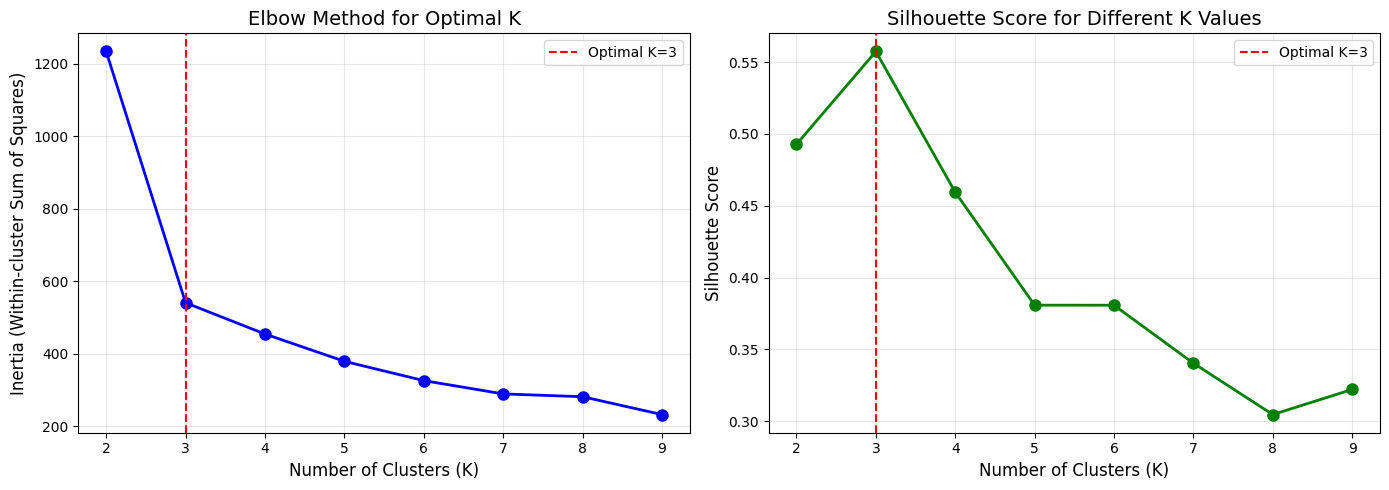


Optimal K based on Silhouette Score: 3
Best Silhouette Score: 0.5574


In [82]:
from sklearn.metrics import silhouette_score

# Elbow Method and Silhouette Analysis
k_range = range(2, 10)
inertias = []
silhouette_scores = []

for k in k_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42)
    kmeans_temp.fit(X)
    inertias.append(kmeans_temp.inertia_)
    silhouette_scores.append(silhouette_score(X, kmeans_temp.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow Plot
axes[0].plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].axvline(x=3, color='r', linestyle='--', label='Optimal K=3')
axes[0].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[0].set_ylabel('Inertia (Within-cluster Sum of Squares)', fontsize=12)
axes[0].set_title('Elbow Method for Optimal K', fontsize=14)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Silhouette Score Plot
axes[1].plot(k_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
axes[1].axvline(x=3, color='r', linestyle='--', label='Optimal K=3')
axes[1].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Score for Different K Values', fontsize=14)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nOptimal K based on Silhouette Score: {k_range[np.argmax(silhouette_scores)]}")
print(f"Best Silhouette Score: {max(silhouette_scores):.4f}")

### Visualize K-Means Results

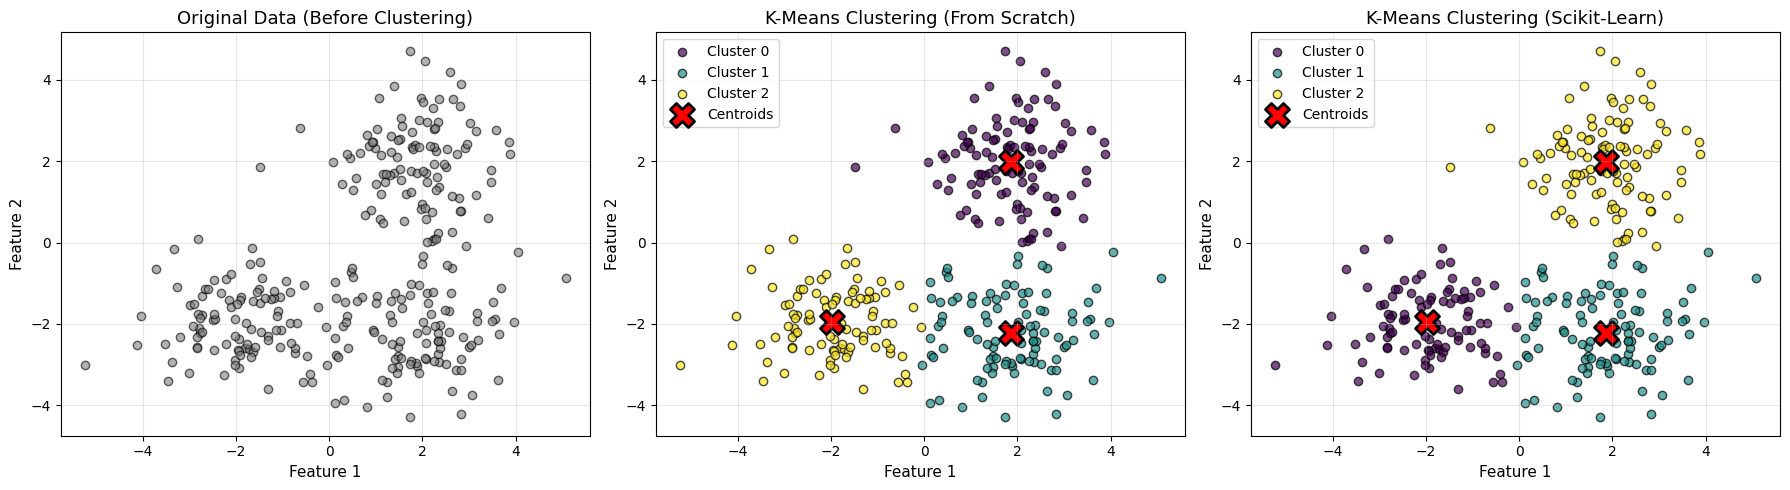


=== Cluster Statistics ===
Cluster 0: 104 samples
  Centroid: (1.873, 1.976)
Cluster 1: 101 samples
  Centroid: (1.874, -2.215)
Cluster 2: 95 samples
  Centroid: (-1.971, -1.965)


In [83]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Original Data (Before Clustering)
scatter1 = axes[0].scatter(X[:, 0], X[:, 1], c='gray', alpha=0.6, edgecolors='black')
axes[0].set_xlabel('Feature 1', fontsize=11)
axes[0].set_ylabel('Feature 2', fontsize=11)
axes[0].set_title('Original Data (Before Clustering)', fontsize=13)
axes[0].grid(True, alpha=0.3)

# K-Means From Scratch
colors = plt.cm.viridis(np.linspace(0, 1, 3))
for i in range(3):
    mask = labels == i
    axes[1].scatter(X[mask, 0], X[mask, 1], c=[colors[i]], alpha=0.7, label=f'Cluster {i}', edgecolors='black')
axes[1].scatter(kmeans.centroids[:, 0], kmeans.centroids[:, 1], c='red', marker='X', s=300, edgecolors='black', linewidths=2, label='Centroids')
axes[1].set_xlabel('Feature 1', fontsize=11)
axes[1].set_ylabel('Feature 2', fontsize=11)
axes[1].set_title('K-Means Clustering (From Scratch)', fontsize=13)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# K-Means Scikit-Learn
for i in range(3):
    mask = labels_sklearn == i
    axes[2].scatter(X[mask, 0], X[mask, 1], c=[colors[i]], alpha=0.7, label=f'Cluster {i}', edgecolors='black')
axes[2].scatter(kmeans_sklearn.cluster_centers_[:, 0], kmeans_sklearn.cluster_centers_[:, 1], c='red', marker='X', s=300, edgecolors='black', linewidths=2, label='Centroids')
axes[2].set_xlabel('Feature 1', fontsize=11)
axes[2].set_ylabel('Feature 2', fontsize=11)
axes[2].set_title('K-Means Clustering (Scikit-Learn)', fontsize=13)
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Cluster Statistics
print("\n=== Cluster Statistics ===")
for i in range(3):
    mask = labels == i
    print(f"Cluster {i}: {np.sum(mask)} samples")
    print(f"  Centroid: ({kmeans.centroids[i, 0]:.3f}, {kmeans.centroids[i, 1]:.3f})")

## 3. Hierarchical Clustering

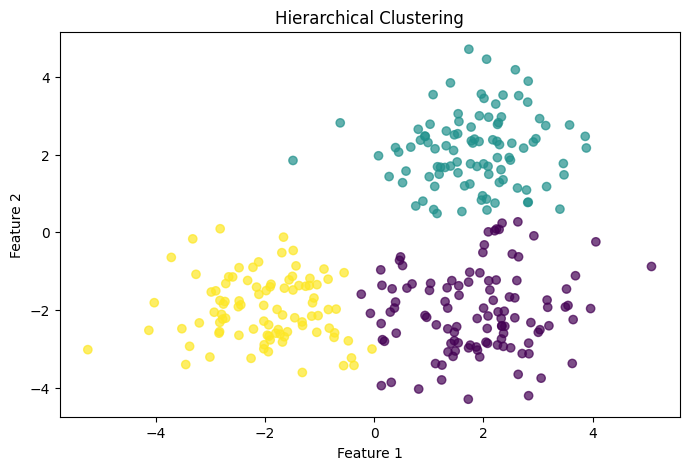

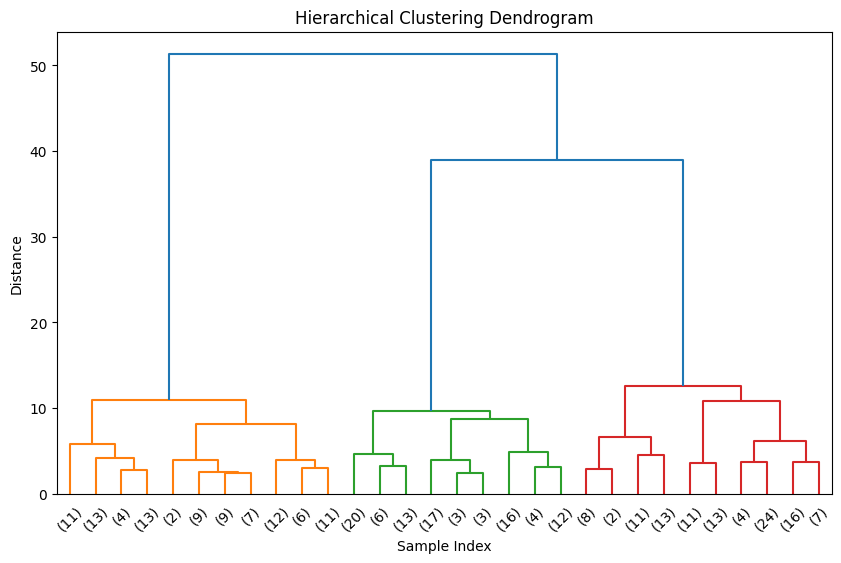

In [84]:
from scipy.cluster.hierarchy import dendrogram, linkage

# Hierarchical Clustering using Scikit-Learn
hc = AgglomerativeClustering(n_clusters=3, linkage='ward')
labels_hc = hc.fit_predict(X)

plt.figure(figsize=(8, 5))
plt.scatter(X[:, 0], X[:, 1], c=labels_hc, cmap='viridis', alpha=0.7)
plt.title('Hierarchical Clustering')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

# Dendrogram
plt.figure(figsize=(10, 6))
Z = linkage(X, method='ward')
dendrogram(Z, truncate_mode='lastp', p=30)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.show()

## 4. Dimensionality Reduction: PCA

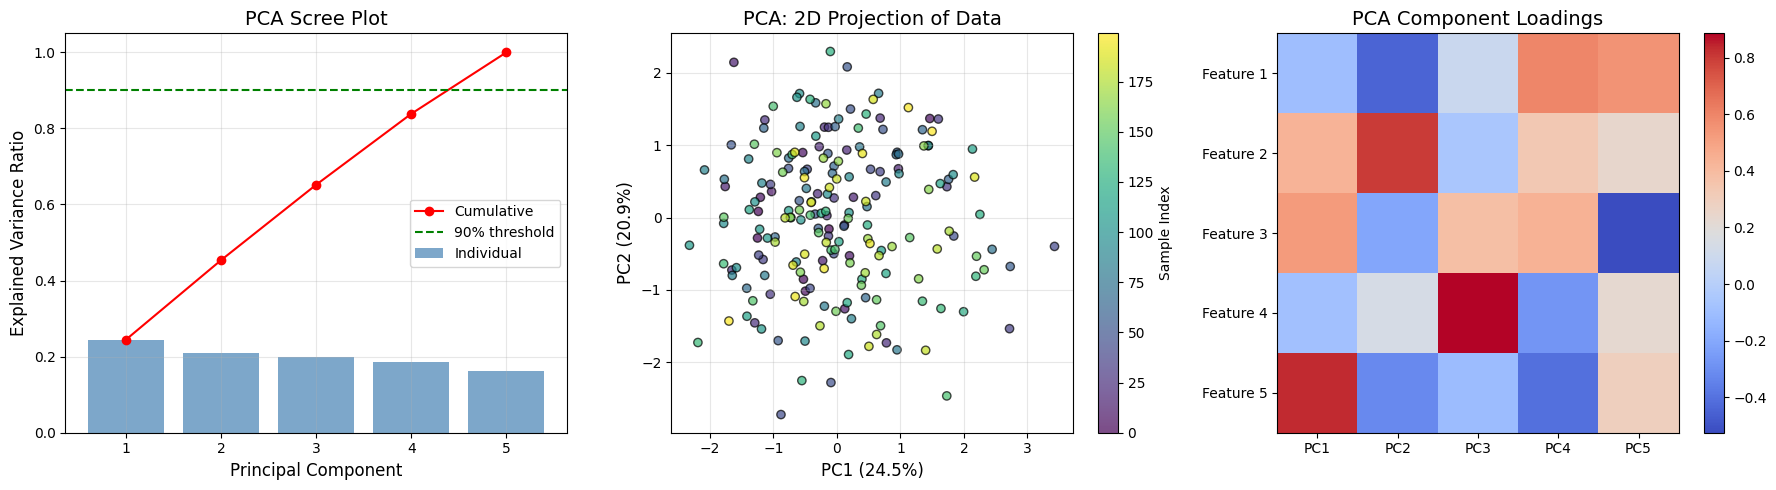

=== PCA Dimensionality Reduction ===
Original shape: (200, 5)
Reduced shape: (200, 2)
Explained variance ratio: [0.24505332 0.20890343]
Total variance explained: 0.4540


In [85]:
# Generate higher-dimensional data with structure
np.random.seed(42)
X_high = np.random.randn(200, 5)

# Apply PCA
pca = PCA()
X_pca_full = pca.fit_transform(X_high)

# Explained variance analysis
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Scree Plot
axes[0].bar(range(1, 6), explained_variance, alpha=0.7, color='steelblue', label='Individual')
axes[0].plot(range(1, 6), cumulative_variance, 'ro-', label='Cumulative')
axes[0].axhline(y=0.9, color='g', linestyle='--', label='90% threshold')
axes[0].set_xlabel('Principal Component', fontsize=12)
axes[0].set_ylabel('Explained Variance Ratio', fontsize=12)
axes[0].set_title('PCA Scree Plot', fontsize=14)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2D PCA Projection
pca_2d = PCA(n_components=2)
X_pca = pca_2d.fit_transform(X_high)
scatter = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=np.arange(len(X_pca)), cmap='viridis', alpha=0.7, edgecolors='black')
axes[1].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
axes[1].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
axes[1].set_title('PCA: 2D Projection of Data', fontsize=14)
axes[1].grid(True, alpha=0.3)
plt.colorbar(scatter, ax=axes[1], label='Sample Index')

# Component Loadings Heatmap
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
im = axes[2].imshow(loadings, cmap='coolwarm', aspect='auto')
axes[2].set_xticks(range(5))
axes[2].set_xticklabels([f'PC{i+1}' for i in range(5)])
axes[2].set_yticks(range(5))
axes[2].set_yticklabels([f'Feature {i+1}' for i in range(5)])
axes[2].set_title('PCA Component Loadings', fontsize=14)
plt.colorbar(im, ax=axes[2])

plt.tight_layout()
plt.show()

print("=== PCA Dimensionality Reduction ===")
print(f"Original shape: {X_high.shape}")
print(f"Reduced shape: {X_pca.shape}")
print(f"Explained variance ratio: {pca_2d.explained_variance_ratio_}")
print(f"Total variance explained: {sum(pca_2d.explained_variance_ratio_):.4f}")

## 5. t-SNE Visualization

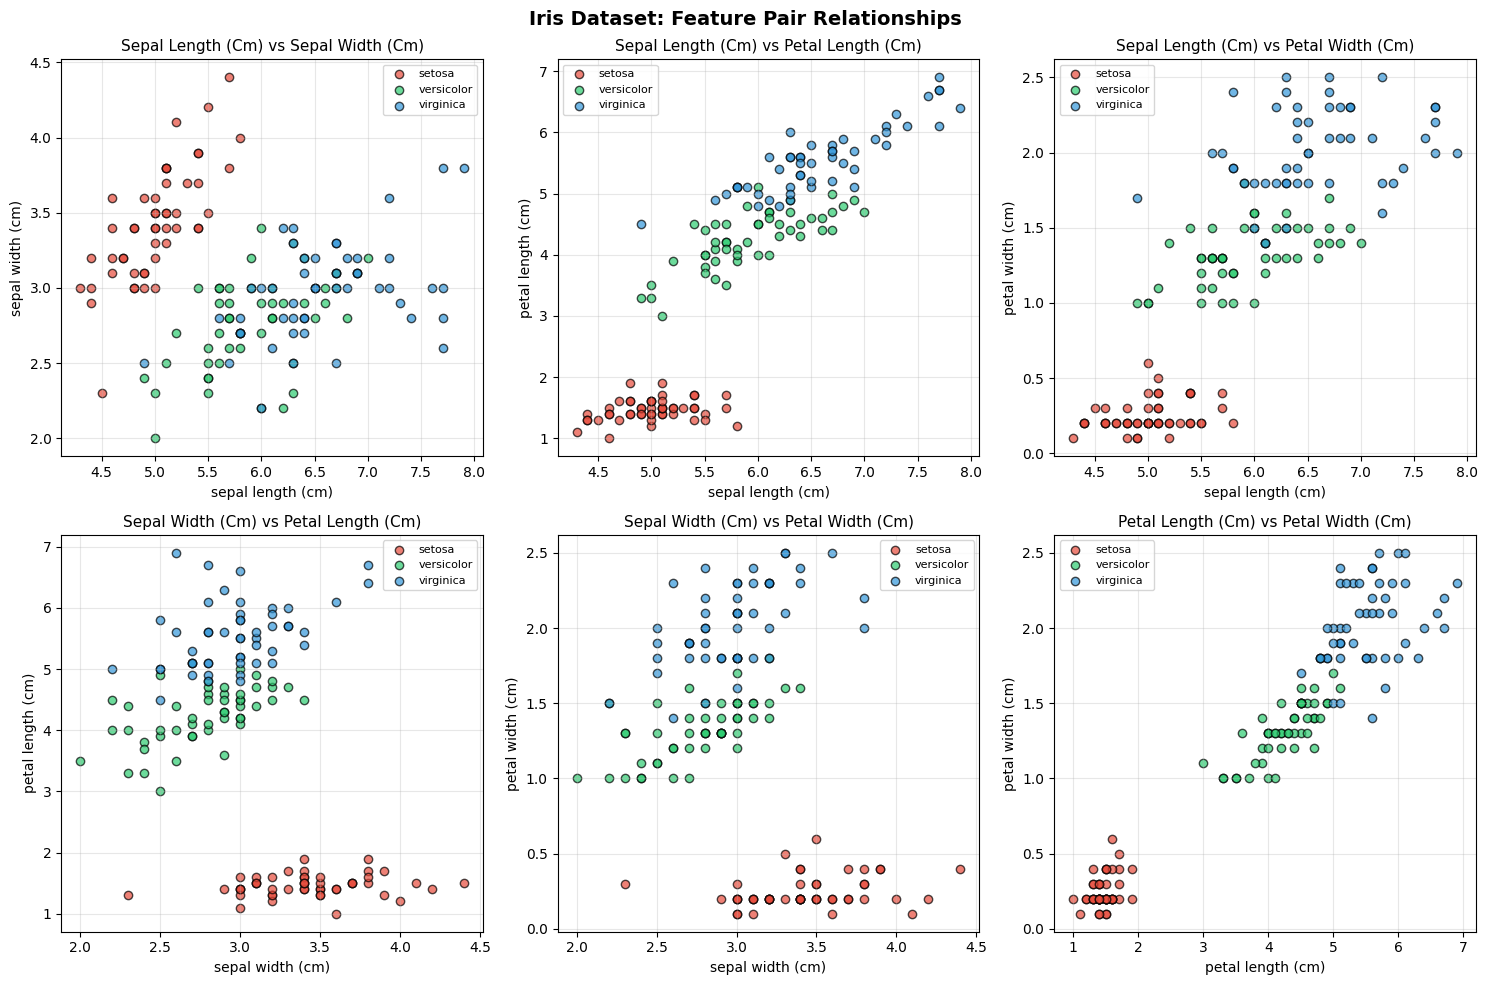

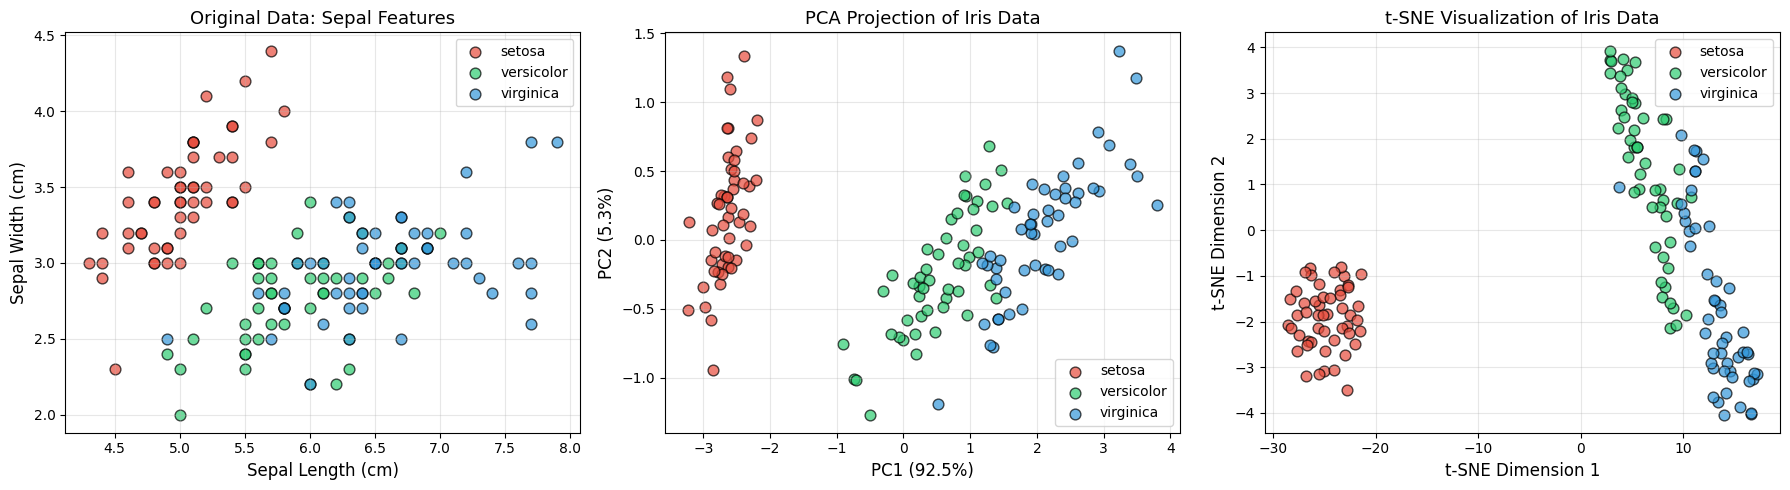

=== Cluster Quality Analysis ===
K=2: Silhouette Score = 0.6810
K=3: Silhouette Score = 0.5512


In [86]:
from sklearn.datasets import load_iris

# Use iris dataset
iris = load_iris()
X_iris = iris.data
y_iris = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

# Apply t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_iris)

# Visualize all feature pairs
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Original feature pairs colored by true labels
feature_pairs = [(0, 1), (0, 2), (0, 3), (1, 2), (1, 3), (2, 3)]
colors = ['#e74c3c', '#2ecc71', '#3498db']

for idx, (i, j) in enumerate(feature_pairs):
    ax = axes[idx // 3, idx % 3]
    for label in range(3):
        mask = y_iris == label
        ax.scatter(X_iris[mask, i], X_iris[mask, j], c=colors[label], 
                   label=target_names[label], alpha=0.7, edgecolors='black')
    ax.set_xlabel(feature_names[i], fontsize=10)
    ax.set_ylabel(feature_names[j], fontsize=10)
    ax.set_title(f'{feature_names[i].title()} vs {feature_names[j].title()}', fontsize=11)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Iris Dataset: Feature Pair Relationships', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# t-SNE comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Original first two features
for label in range(3):
    mask = y_iris == label
    axes[0].scatter(X_iris[mask, 0], X_iris[mask, 1], c=colors[label], 
                    label=target_names[label], alpha=0.7, s=60, edgecolors='black')
axes[0].set_xlabel('Sepal Length (cm)', fontsize=12)
axes[0].set_ylabel('Sepal Width (cm)', fontsize=12)
axes[0].set_title('Original Data: Sepal Features', fontsize=13)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# PCA projection
pca_iris = PCA(n_components=2)
X_pca_iris = pca_iris.fit_transform(X_iris)
for label in range(3):
    mask = y_iris == label
    axes[1].scatter(X_pca_iris[mask, 0], X_pca_iris[mask, 1], c=colors[label], 
                    label=target_names[label], alpha=0.7, s=60, edgecolors='black')
axes[1].set_xlabel(f'PC1 ({pca_iris.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
axes[1].set_ylabel(f'PC2 ({pca_iris.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
axes[1].set_title('PCA Projection of Iris Data', fontsize=13)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# t-SNE
for label in range(3):
    mask = y_iris == label
    axes[2].scatter(X_tsne[mask, 0], X_tsne[mask, 1], c=colors[label], 
                    label=target_names[label], alpha=0.7, s=60, edgecolors='black')
axes[2].set_xlabel('t-SNE Dimension 1', fontsize=12)
axes[2].set_ylabel('t-SNE Dimension 2', fontsize=12)
axes[2].set_title('t-SNE Visualization of Iris Data', fontsize=13)
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Cluster quality analysis with t-SNE
from sklearn.metrics import silhouette_score
print("=== Cluster Quality Analysis ===")
for n_clusters in [2, 3]:
    kmeans_temp = KMeans(n_clusters=n_clusters, random_state=42)
    labels_temp = kmeans_temp.fit_predict(X_iris)
    score = silhouette_score(X_iris, labels_temp)
    print(f"K={n_clusters}: Silhouette Score = {score:.4f}")

## 6. Market Basket Analysis

### Association Rule Mining with Apriori Algorithm

In [87]:
# Create sample market basket data
transactions = [
    ['milk', 'bread', 'eggs'],
    ['bread', 'butter', 'eggs'],
    ['milk', 'bread', 'butter'],
    ['bread', 'eggs'],
    ['milk', 'eggs'],
    ['bread', 'milk', 'eggs'],
    ['butter', 'eggs'],
    ['milk', 'bread', 'butter', 'eggs'],
    ['milk', 'butter'],
    ['eggs', 'bread']
]

print("Sample Transactions:")
for i, t in enumerate(transactions[:5]):
    print(f"Transaction {i+1}: {t}")

Sample Transactions:
Transaction 1: ['milk', 'bread', 'eggs']
Transaction 2: ['bread', 'butter', 'eggs']
Transaction 3: ['milk', 'bread', 'butter']
Transaction 4: ['bread', 'eggs']
Transaction 5: ['milk', 'eggs']


### Encode Transactions

In [88]:
# Encode transactions using TransactionEncoder
te = TransactionEncoder()
te_array = te.fit_transform(transactions)
df = pd.DataFrame(te_array, columns=te.columns_)

print("Encoded Transaction Data:")
print(df.head())

Encoded Transaction Data:
   bread  butter   eggs   milk
0   True   False   True   True
1   True    True   True  False
2   True    True  False   True
3   True   False   True  False
4  False   False   True   True


### Apply Apriori Algorithm

In [89]:
# Find frequent itemsets with minimum support of 0.3
frequent_itemsets = apriori(df, min_support=0.3, use_colnames=True)

print("=== Frequent Itemsets ===")
print(frequent_itemsets.sort_values('support', ascending=False))

=== Frequent Itemsets ===
    support                        itemsets
2       0.8               frozenset({eggs})
0       0.7              frozenset({bread})
3       0.6               frozenset({milk})
5       0.6        frozenset({eggs, bread})
1       0.5             frozenset({butter})
6       0.4        frozenset({milk, bread})
9       0.4         frozenset({milk, eggs})
4       0.3      frozenset({butter, bread})
7       0.3       frozenset({butter, eggs})
8       0.3       frozenset({butter, milk})
10      0.3  frozenset({milk, eggs, bread})


### Generate Association Rules

In [90]:
# Generate association rules with minimum confidence of 0.5
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.5)

print("\n=== Association Rules ===")
if len(rules) > 0:
    rules_display = rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].sort_values('lift', ascending=False)
    rules_display['antecedents'] = rules_display['antecedents'].apply(lambda x: ', '.join(list(x)))
    rules_display['consequents'] = rules_display['consequents'].apply(lambda x: ', '.join(list(x)))
    print(rules_display.to_string(index=False))
else:
    print("No rules found with the given thresholds.")


=== Association Rules ===
antecedents consequents  support  confidence     lift
       eggs       bread      0.6    0.750000 1.071429
      bread        eggs      0.6    0.857143 1.071429
 milk, eggs       bread      0.3    0.750000 1.071429
     butter        milk      0.3    0.600000 1.000000
       milk      butter      0.3    0.500000 1.000000
      bread        milk      0.4    0.571429 0.952381
       milk       bread      0.4    0.666667 0.952381
milk, bread        eggs      0.3    0.750000 0.937500
     butter       bread      0.3    0.600000 0.857143
       eggs        milk      0.4    0.500000 0.833333
eggs, bread        milk      0.3    0.500000 0.833333
       milk        eggs      0.4    0.666667 0.833333
       milk eggs, bread      0.3    0.500000 0.833333
     butter        eggs      0.3    0.600000 0.750000


### Larger Market Basket Dataset

In [91]:
# Generate larger synthetic dataset
np.random.seed(42)
n_transactions = 100

items = ['milk', 'bread', 'eggs', 'butter', 'cheese', 'yogurt', 'rice', 'pasta', 'tomatoes', 'onions']

def generate_transaction():
    n_items = np.random.randint(2, 7)
    return list(np.random.choice(items, n_items, replace=False))

large_transactions = [generate_transaction() for _ in range(n_transactions)]

# Encode
te_large = TransactionEncoder()
te_array_large = te_large.fit_transform(large_transactions)
df_large = pd.DataFrame(te_array_large, columns=te_large.columns_)

print(f"Dataset: {n_transactions} transactions, {len(items)} items")
print(f"\nSample transactions:")
for i in range(3):
    print(f"{i+1}. {large_transactions[i]}")

Dataset: 100 transactions, 10 items

Sample transactions:
1. [np.str_('butter'), np.str_('onions'), np.str_('milk'), np.str_('tomatoes'), np.str_('yogurt')]
2. [np.str_('tomatoes'), np.str_('eggs'), np.str_('milk'), np.str_('rice')]
3. [np.str_('bread'), np.str_('pasta'), np.str_('rice'), np.str_('eggs'), np.str_('tomatoes')]


### Frequent Itemsets (Larger Dataset)

In [92]:
# Find frequent itemsets
frequent_large = apriori(df_large, min_support=0.1, use_colnames=True)
frequent_large = frequent_large.sort_values('support', ascending=False)

# Fix mlxtend/numpy compatibility issue
frequent_large['itemsets'] = frequent_large['itemsets'].apply(
    lambda x: frozenset(str(item) for item in x)
)

# Keep original for association_rules, create display version separately
print("=== Frequent Itemsets (Support >= 0.1) ===")
frequent_itemsets_list = []
for _, row in frequent_large.iterrows():
    frequent_itemsets_list.append({
        'itemsets': ', '.join(sorted(list(row['itemsets']))),
        'support': row['support']
    })
frequent_display = pd.DataFrame(frequent_itemsets_list)
print(frequent_display.head(10).to_string(index=False))

=== Frequent Itemsets (Support >= 0.1) ===
itemsets  support
  cheese     0.48
   bread     0.46
    eggs     0.43
  yogurt     0.43
tomatoes     0.43
   pasta     0.41
  onions     0.38
    milk     0.37
  butter     0.35
    rice     0.33


### Association Rules (Larger Dataset)

In [93]:
# Generate rules
rules_large = association_rules(frequent_large, metric="confidence", min_threshold=0.3)
rules_large = rules_large.sort_values('lift', ascending=False)

print("\n=== Top Association Rules ===")
rules_display_list = []
for _, row in rules_large.head(10).iterrows():
    rules_display_list.append({
        'antecedents': ', '.join(sorted(list(row['antecedents']))),
        'consequents': ', '.join(sorted(list(row['consequents']))),
        'support': row['support'],
        'confidence': row['confidence'],
        'lift': row['lift']
    })
rules_display = pd.DataFrame(rules_display_list)
print(rules_display.to_string(index=False))


=== Top Association Rules ===
    antecedents  consequents  support  confidence     lift
         butter bread, pasta     0.11    0.314286 1.571429
   bread, pasta       butter     0.11    0.550000 1.571429
  bread, butter        pasta     0.11    0.611111 1.490515
    milk, pasta       cheese     0.10    0.666667 1.388889
  pasta, yogurt       cheese     0.12    0.666667 1.388889
pasta, tomatoes        bread     0.11    0.611111 1.328502
  butter, pasta        bread     0.11    0.611111 1.328502
   cheese, eggs       yogurt     0.10    0.555556 1.291990
   bread, pasta     tomatoes     0.11    0.550000 1.279070
   cheese, milk       yogurt     0.11    0.550000 1.279070


### Visualize Rules

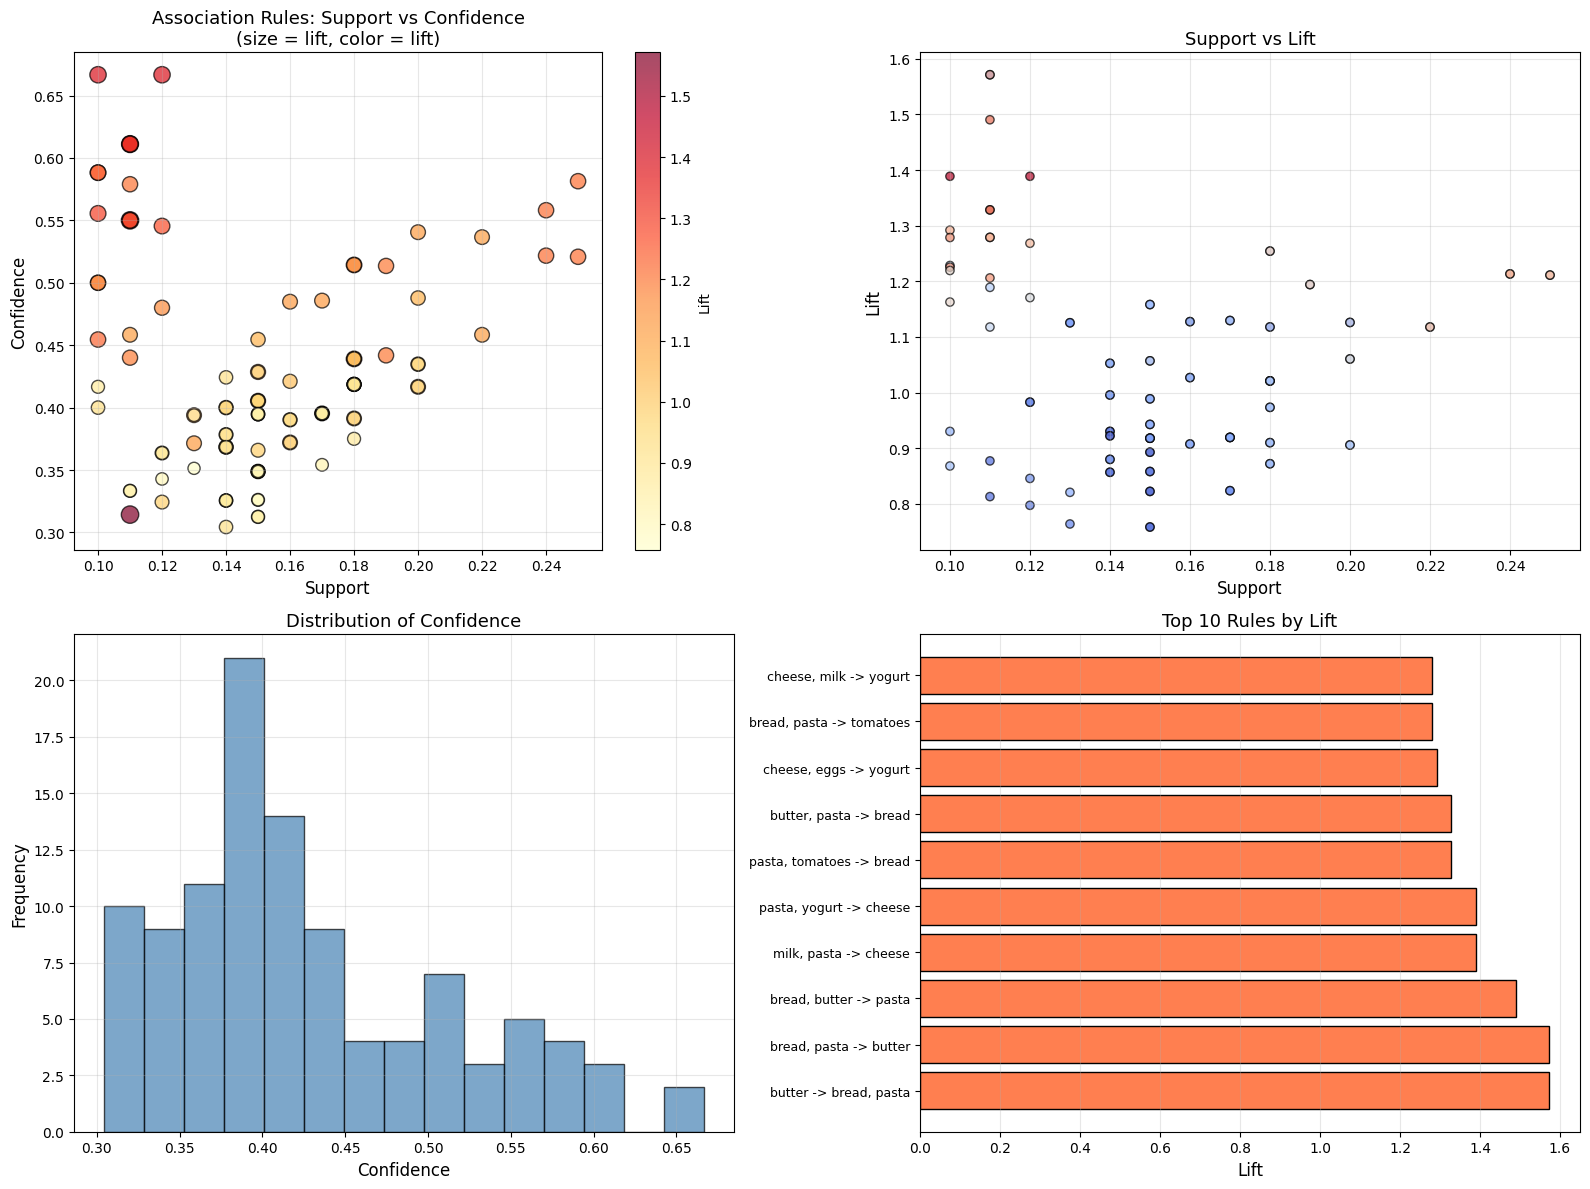

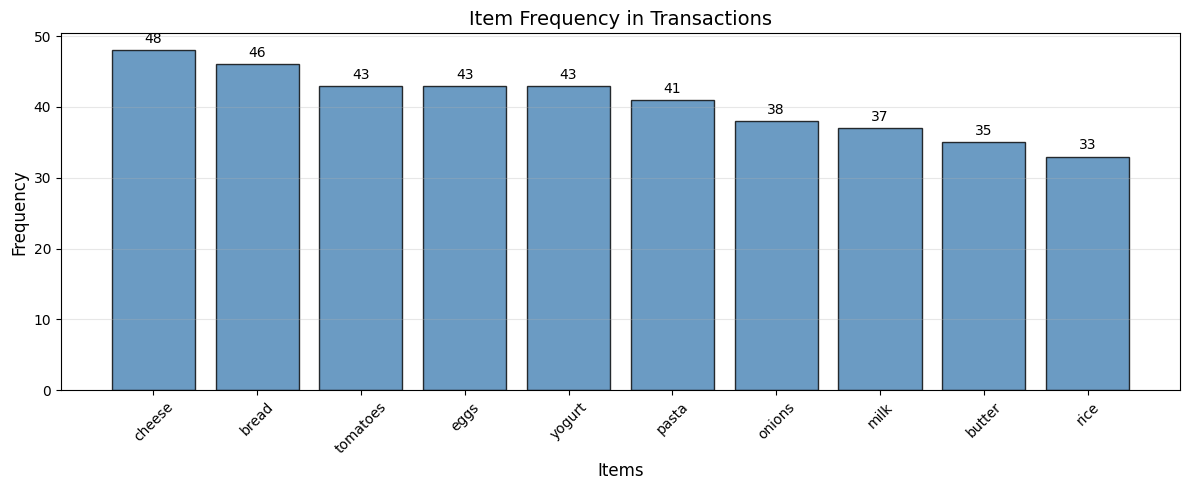

In [94]:
if len(rules_large) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Scatter plot: Support vs Confidence
    scatter = axes[0, 0].scatter(rules_large['support'], rules_large['confidence'], 
                alpha=0.7, s=rules_large['lift']*100, c=rules_large['lift'], cmap='YlOrRd', edgecolors='black')
    axes[0, 0].set_xlabel('Support', fontsize=12)
    axes[0, 0].set_ylabel('Confidence', fontsize=12)
    axes[0, 0].set_title('Association Rules: Support vs Confidence\n(size = lift, color = lift)', fontsize=13)
    plt.colorbar(scatter, ax=axes[0, 0], label='Lift')
    axes[0, 0].grid(True, alpha=0.3)
    
    # Support vs Lift
    axes[0, 1].scatter(rules_large['support'], rules_large['lift'], 
                alpha=0.7, c=rules_large['confidence'], cmap='coolwarm', edgecolors='black')
    axes[0, 1].set_xlabel('Support', fontsize=12)
    axes[0, 1].set_ylabel('Lift', fontsize=12)
    axes[0, 1].set_title('Support vs Lift', fontsize=13)
    axes[0, 1].grid(True, alpha=0.3)
    
    # Confidence distribution
    axes[1, 0].hist(rules_large['confidence'], bins=15, color='steelblue', alpha=0.7, edgecolor='black')
    axes[1, 0].set_xlabel('Confidence', fontsize=12)
    axes[1, 0].set_ylabel('Frequency', fontsize=12)
    axes[1, 0].set_title('Distribution of Confidence', fontsize=13)
    axes[1, 0].grid(True, alpha=0.3)
    
    # Top rules bar chart
    top_10_rules = rules_large.head(10).copy()
    rule_labels = [f"{', '.join(sorted(list(a)))} -> {', '.join(sorted(list(c)))}" 
                   for a, c in zip(top_10_rules['antecedents'], top_10_rules['consequents'])]
    axes[1, 1].barh(range(len(top_10_rules)), top_10_rules['lift'].values, color='coral', edgecolor='black')
    axes[1, 1].set_yticks(range(len(top_10_rules)))
    axes[1, 1].set_yticklabels(rule_labels, fontsize=9)
    axes[1, 1].set_xlabel('Lift', fontsize=12)
    axes[1, 1].set_title('Top 10 Rules by Lift', fontsize=13)
    axes[1, 1].grid(True, alpha=0.3, axis='x')
    
    plt.tight_layout()
    plt.show()
    
    # Item frequency heatmap
    item_counts = df_large.sum().sort_values(ascending=False)
    fig, ax = plt.subplots(figsize=(12, 5))
    bars = ax.bar(item_counts.index, item_counts.values, color='steelblue', edgecolor='black', alpha=0.8)
    ax.set_xlabel('Items', fontsize=12)
    ax.set_ylabel('Frequency', fontsize=12)
    ax.set_title('Item Frequency in Transactions', fontsize=14)
    ax.grid(True, alpha=0.3, axis='y')
    for bar, val in zip(bars, item_counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, str(val), ha='center', fontsize=10)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## 7. Comprehensive Visualization Summary

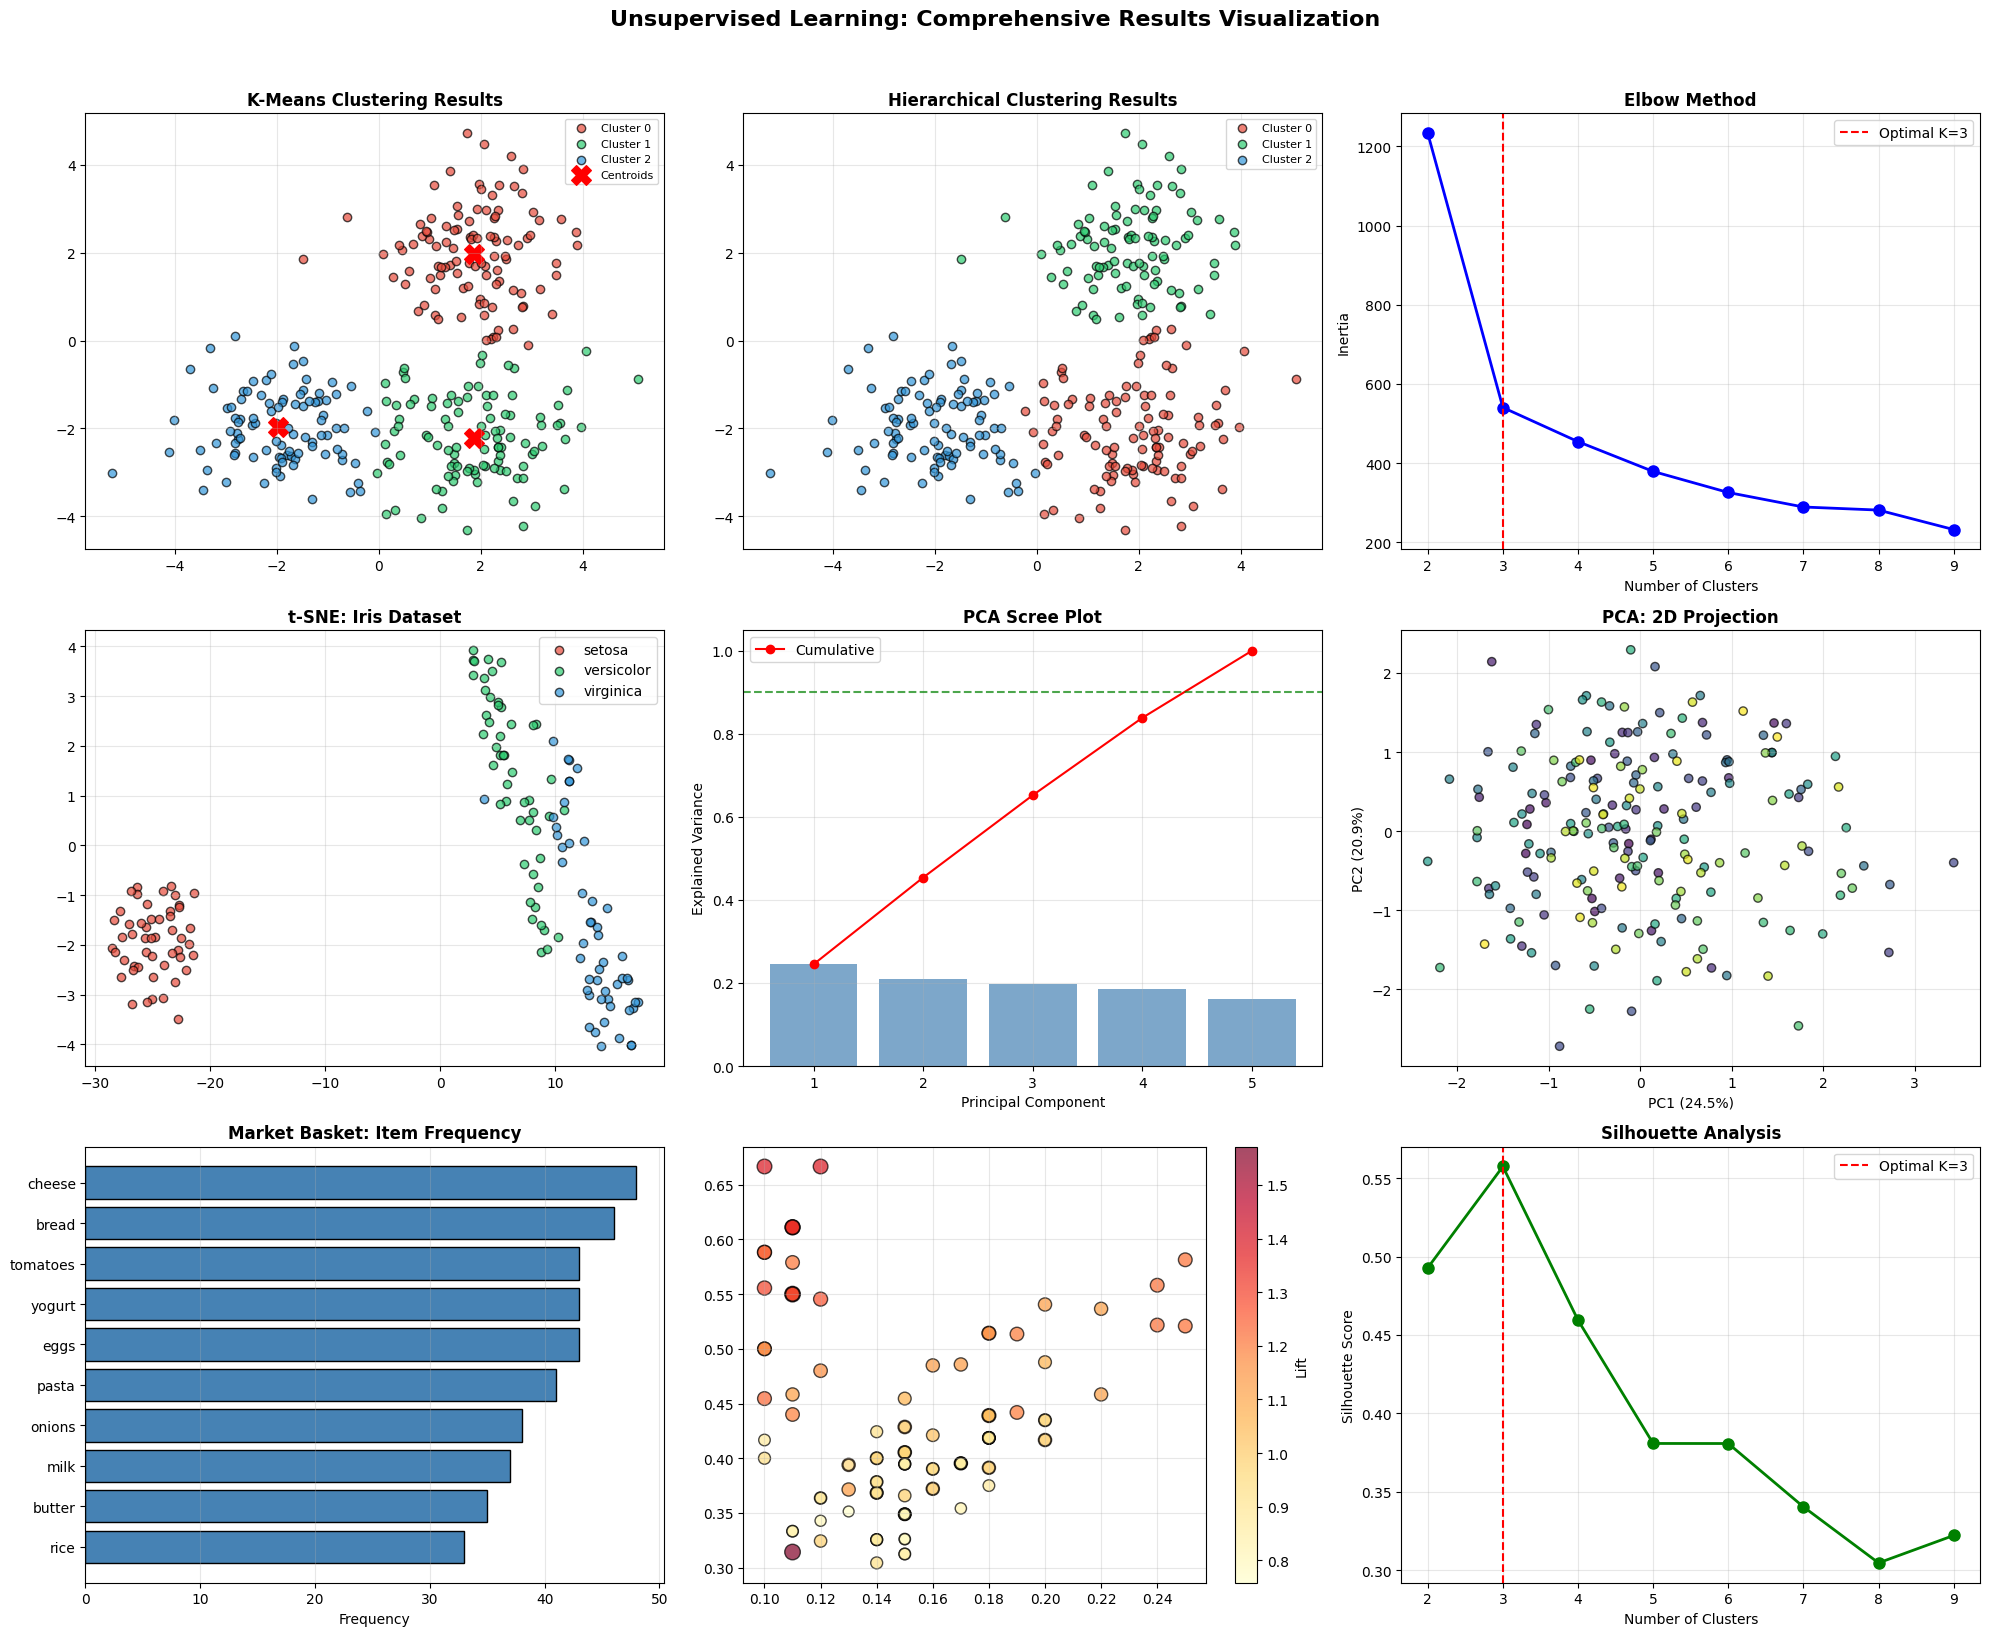

In [95]:
# Final comprehensive visualization
fig = plt.figure(figsize=(20, 16))

# 1. K-Means Clustering Results
ax1 = fig.add_subplot(3, 3, 1)
for i in range(3):
    mask = labels == i
    ax1.scatter(X[mask, 0], X[mask, 1], c=[colors[i]], alpha=0.7, label=f'Cluster {i}', edgecolors='black')
ax1.scatter(kmeans.centroids[:, 0], kmeans.centroids[:, 1], c='red', marker='X', s=200, label='Centroids')
ax1.set_title('K-Means Clustering Results', fontsize=12, fontweight='bold')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

# 2. Hierarchical Clustering
ax2 = fig.add_subplot(3, 3, 2)
for i in range(3):
    mask = labels_hc == i
    ax2.scatter(X[mask, 0], X[mask, 1], c=[colors[i]], alpha=0.7, label=f'Cluster {i}', edgecolors='black')
ax2.set_title('Hierarchical Clustering Results', fontsize=12, fontweight='bold')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

# 3. Elbow Method
ax3 = fig.add_subplot(3, 3, 3)
ax3.plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
ax3.axvline(x=3, color='r', linestyle='--', label='Optimal K=3')
ax3.set_xlabel('Number of Clusters')
ax3.set_ylabel('Inertia')
ax3.set_title('Elbow Method', fontsize=12, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. t-SNE Iris
ax4 = fig.add_subplot(3, 3, 4)
for label in range(3):
    mask = y_iris == label
    ax4.scatter(X_tsne[mask, 0], X_tsne[mask, 1], c=colors[label], 
                label=target_names[label], alpha=0.7, edgecolors='black')
ax4.set_title('t-SNE: Iris Dataset', fontsize=12, fontweight='bold')
ax4.legend()
ax4.grid(True, alpha=0.3)

# 5. PCA Scree Plot
ax5 = fig.add_subplot(3, 3, 5)
ax5.bar(range(1, 6), explained_variance, alpha=0.7, color='steelblue')
ax5.plot(range(1, 6), cumulative_variance, 'ro-', label='Cumulative')
ax5.axhline(y=0.9, color='g', linestyle='--', alpha=0.7)
ax5.set_xlabel('Principal Component')
ax5.set_ylabel('Explained Variance')
ax5.set_title('PCA Scree Plot', fontsize=12, fontweight='bold')
ax5.legend()
ax5.grid(True, alpha=0.3)

# 6. PCA 2D Projection
ax6 = fig.add_subplot(3, 3, 6)
scatter = ax6.scatter(X_pca[:, 0], X_pca[:, 1], c=np.arange(len(X_pca)), cmap='viridis', alpha=0.7, edgecolors='black')
ax6.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
ax6.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
ax6.set_title('PCA: 2D Projection', fontsize=12, fontweight='bold')
ax6.grid(True, alpha=0.3)

# 7. Item Frequency
ax7 = fig.add_subplot(3, 3, 7)
item_counts = df_large.sum().sort_values(ascending=True)
ax7.barh(item_counts.index, item_counts.values, color='steelblue', edgecolor='black')
ax7.set_xlabel('Frequency')
ax7.set_title('Market Basket: Item Frequency', fontsize=12, fontweight='bold')
ax7.grid(True, alpha=0.3, axis='x')

# 8. Association Rules Scatter
ax8 = fig.add_subplot(3, 3, 8)
if len(rules_large) > 0:
    scatter = ax8.scatter(rules_large['support'], rules_large['confidence'], 
                alpha=0.7, s=rules_large['lift']*80, c=rules_large['lift'], cmap='YlOrRd', edgecolors='black')
    plt.colorbar(scatter, ax=ax8, label='Lift')
else:
    ax8.text(0.5, 0.5, 'No rules found', ha='center', va='center', fontsize=12)
ax8.grid(True, alpha=0.3)

# 9. Silhouette Scores
ax9 = fig.add_subplot(3, 3, 9)
ax9.plot(k_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
ax9.axvline(x=3, color='r', linestyle='--', label='Optimal K=3')
ax9.set_xlabel('Number of Clusters')
ax9.set_ylabel('Silhouette Score')
ax9.set_title('Silhouette Analysis', fontsize=12, fontweight='bold')
ax9.legend()
ax9.grid(True, alpha=0.3)

plt.suptitle('Unsupervised Learning: Comprehensive Results Visualization', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 8. Summary

### Key Concepts Covered:

1. **K-Means Clustering**: Unsupervised algorithm for partitioning data into K clusters
2. **Hierarchical Clustering**: Creates hierarchy of clusters with dendrogram visualization
3. **PCA**: Principal Component Analysis for dimensionality reduction
4. **t-SNE**: Non-linear dimensionality reduction for visualization
5. **Association Rule Mining**: Apriori algorithm for market basket analysis

### Key Metrics:
- **Support**: Frequency of itemset in transactions
- **Confidence**: P(B|A) - probability of B given A
- **Lift**: How much A increases the probability of B